<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller: Identificando  Burger Master con MMG

El Burger Master es un evento creado en el 2016 por el *influencer* Tulio Zuluaga, más conocido en redes como Tulio recomienda, el cual busca que por una semana las hamburgueserías de cada ciudad ofrezcan su mejor producto a un precio reducido. 

El evento ha venido creciendo y en el 2022 se extendió por 21 ciudades de Colombia para las cuales se estimó que se vendieron más de dos millones de hamburguesas. El objetivo del presente caso-taller  es identificar los puntos calientes de hamburgueserías  que compitieron en  la ciudad de Bogotá aplicando el Modelo de Mezclas Gaussianas.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "Revisión por el compañero."

4. El archivo entregado debe poder ser ejecutado localmente por los pares. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos  en la misma ruta de acceso del cuaderno, por ejemplo: `data`.


## Integrante

|**Nombre**|**Email**|
|---|---|
|Mendoza Canales Hubert Ronald|h.mendozac@uniandes.edu.co|

## Desarrollo

#### Config

In [188]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

# python
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm # Para las paletas de colores
from matplotlib.colors import to_rgba
from matplotlib.patches import Ellipse
import session_info

# tools
import re
import json
from pathlib import Path
from inspect import cleandoc
from dataclasses import dataclass
from unidecode import unidecode
from enum import Enum

# stats
from statsmodels.nonparametric.kernel_density import KDEMultivariate


# Geo
import folium
import geojsoncontour
import geopandas as gpd


# sklearn
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV


# typings
from typing import Dict, Any, Optional

# Omitir advertencias
import warnings
from sklearn.exceptions import FitFailedWarning
# from sklearn.model_selection import ConvergenceWarning, UserWarning, FutureWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings('ignore', category=FitFailedWarning)
# warnings.filterwarnings('ignore', category=ConvergenceWarning)
# warnings.filterwarnings("ignore", category=UserWarning) 
# warnings.filterwarnings("ignore", category=FutureWarning)


# setup
plt.style.use('seaborn')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)

# decimals
np.set_printoptions(precision=6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


##### Información de Sesión

In [189]:
session_info.show(html=False)

-----
folium              0.14.0
geojsoncontour      NA
geopandas           0.10.2
geopy               2.4.0
matplotlib          3.3.1
numpy               1.19.1
pandas              1.1.1
pyrosm              NA
scipy               1.7.3
seaborn             0.12.2
session_info        1.0.0
shapely             1.8.5
sklearn             0.23.2
statsmodels         0.13.5
unidecode           NA
-----
IPython             7.34.0
jupyter_client      7.4.9
jupyter_core        4.12.0
jupyterlab          2.1.1
notebook            6.0.3
-----
Python 3.7.17 (default, Jun 13 2023, 16:36:15) [GCC 8.3.0]
Linux-5.15.49-linuxkit-x86_64-with-debian-10.13
-----
Session information updated at 2025-09-29 04:13


### utils

In [190]:
# utils
# rutas absolutas: agnostico al sistema operativo
here: Path = Path.cwd().absolute()
data: Path = here / 'data'

burger_master_xlsx: Path = data / 'burger_master.xlsx'

### 1. Carga de datos  

En la carpeta `data` se encuentra el archivo `burger_master.xlsx` para la ciudad de Bogotá, cargue estos datos en su *cuaderno* y reporte brevemente el contenido de la base.

In [191]:
# Utilice este espacio para escribir el código.
def clean_colname(name: str) -> str:
    """Limpia el nombre de una cadena de texto.
        esto con la finalidad de llamar luego
        los campos del DataFrame de forma más sencilla.
        a traves de punto como si fueran atributos 
        del DataFrame.

    Args:
        name (str): Nombre a limpiar.

    Returns:
        str: Nombre limpio.
    """
    name = name.strip()  # Elimina espacios en blanco al inicio y al final
    name = unidecode(name)  # Elimina tildes y caracteres especiales
    name = name.lower()  # Convierte a minúsculas
    name = name.replace(' ', '_')  # Reemplaza espacios por guiones bajos
    name = re.sub(r'[^\x00-\x7F]+', '', name)
    return name

bogota_mb_df = pd.read_excel(
    burger_master_xlsx, engine='openpyxl'
).rename(columns=clean_colname)

bogota_mb_df = gpd.GeoDataFrame(
    bogota_mb_df, geometry = gpd.points_from_xy(bogota_mb_df.latitud, bogota_mb_df.longitud)
)
bogota_mb_df.crs = "EPSG:4326" #la proyección WGS84, ya que tenemos la latitudes y longitudes que los ubican en el mapa,
                               #pero luego lo proyectamos a MAGNA-SIRGAS para tener la proyección que corresponde a Bogotá.

print("Dimensiones:", bogota_mb_df.shape)
print("Franquicia de Restaurantes:", bogota_mb_df.restaurante.unique().shape[0], "\n")
print(bogota_mb_df.info())
bogota_mb_df.head(3)

Dimensiones: (137, 6)
Franquicia de Restaurantes: 63 

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   restaurante  137 non-null    object  
 1   direccion    137 non-null    object  
 2   descripcion  137 non-null    object  
 3   latitud      137 non-null    float64 
 4   longitud     137 non-null    float64 
 5   geometry     137 non-null    geometry
dtypes: float64(2), geometry(1), object(3)
memory usage: 6.5+ KB
None


,restaurante,direccion,descripcion,latitud,longitud,geometry
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.668833,-74.116828,POINT (4.66883 -74.11683)
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.698395,-74.036585,POINT (4.69839 -74.03658)
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.686401,-74.060144,POINT (4.68640 -74.06014)


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

Datos que corresponden a la ciudad de Bogotá D.C.

* Registros : 137
* Franquicias de Restaurantes: 63
* Información sobre hamburguesas que se ofrecen en cada restaurante.

| Campo | Tipo de dato | Descripción  |
| --- | --- | --- |
| restaurante | object  | Nombre del restaurante. |
| direccion  | object  | Dirección física del restaurante. |
| descripcion | object  | Breve descripción del restaurante o información adicional relevante sobre su propuesta. Este texto tiene tags en html |
| latitud     | float64 | Latitud geográfica del restaurante en formato decimal.   |
| longitud    | float64 | Longitud geográfica del restaurante en formato decimal.  |
| geometry    | geometry | Al convertirse el dataframe en un GeoDataFrame de geopandas se especifican mediante puntos que surgen a partir de la latitud y longitud   |

<br>

> Nota: "EPSG:4326" la proyección WGS84, ya que tenemos la latitudes y longitudes que los ubican en el mapa, pero luego lo proyectamos a MAGNA-SIRGAS para tener la proyección que corresponde a Bogotá. Esto se emplea para medir distancias, para este taller no se empleará calculo de distancias directamente pero si las Densidades de kernel bivariadas, en tal sentido se deja configurado porque `sm.nonparametric.KDEMultivariate` recibe un GeoDataFrame.

> Nota: En el portal de [Datos Abiertos Bogotá](https://datosabiertos.bogota.gov.co/dataset?q=estratificaci%C3%B3n) se encuentra en formato [GeoJson la Estratificación Manzana Bogotá D.C.](https://datosabiertos.bogota.gov.co/dataset/estratificacion-para-bogota) Geo JavaScript Object Notation (GeoJSON)

In [192]:
bogota_mb_df.loc[bogota_mb_df.restaurante =='GOOD BURGER', :]

,restaurante,direccion,descripcion,latitud,longitud,geometry
65,GOOD BURGER,Calle 150c bis #103f-34,"<p>Esta deliciosa creación está hecha con 150gr de una mezcla de 3 finos cortes de ganado colombiano, pan artesanal de la mejor calidad, sellado en mantequilla y cubierto con nuestra salsa especial GB, queso mozzarella de Búfala 100% hecho en Colombia, cebolla caramelizada en panela de nuestra tierra, carne desmechada con trozos de tocineta ahumada y vegetales frescos logrando la mezcla de sabores magistrales.</p>",4.749888,-74.094196,POINT (4.74989 -74.09420)


### 2.  Visualizando los datos

Visualice la ubicación de cada restaurante en un mapa interactivo. Añada un marcador para cada restaurante y la posibilidad de encontrar la descripción de la hamburguesa ofrecida en un pop-up. (Note que la columna Descripción contiene otra información adicional).

In [193]:
# Utilice este espacio para escribir el código.

# helper
# --- Función para Limpiar la Descripción ---
def limpiar_descripcion_franquicia(html_text: str) -> Optional[str]:
    """
    Extrae la descripción de la hamburguesa, manejando tanto el formato complejo
    (con nombre de franquicia y direcciones anexas) como el formato simple (solo descripción).
    """
    if not isinstance(html_text, str) or not html_text.strip():
        return None
    
    # 1. Patrón COMPLEJO (Para casos como MAIKKI, con el nombre de la burger y direcciones)
    # Busca el texto DESPUÉS del nombre de la franquicia (y los dos puntos)
    # y ANTES del primer <br/> o </p>.
    pattern_complejo = r'<p>.*?:(.*?)(?=<br\/>|<br>|\<\/p>)'
    match_complejo = re.search(pattern_complejo, html_text, re.IGNORECASE | re.DOTALL)
    
    if match_complejo:
        return match_complejo.group(1).strip()
    
    # 2. Patrón SIMPLE (Para casos como GOOD BURGER, donde la descripción es todo el párrafo)
    # Busca todo el contenido (.*?) dentro de las primeras etiquetas <p>...</p>
    pattern_simple = r'<p>(.*?)<\/p>'
    match_simple = re.search(pattern_simple, html_text, re.IGNORECASE | re.DOTALL)
    
    if match_simple:
        # Devuelve el contenido capturado, asegurando que no queden etiquetas dentro
        # y limpiando espacios excesivos.
        texto_limpio = match_simple.group(1).strip()
        
        # Opcional: Quitar cualquier etiqueta <br> que quede al inicio/final si el texto es muy simple.
        texto_limpio = re.sub(r'(^<br\/>|<br\/>$)', '', texto_limpio).strip()
        
        return texto_limpio
        
    return None

# Limpieza de descripcion en dataframe
bogota_mb_df.loc[:,'descripcion_limpia'] =\
    bogota_mb_df.descripcion.apply(limpiar_descripcion_franquicia)

bogota_mb_lat = bogota_mb_df.latitud
bogota_mb_lon = bogota_mb_df.longitud
bogota_mb_location = [bogota_mb_lat.mean(), bogota_mb_lon.mean()]

mapa_bogota_mb = folium.Map(
    location=bogota_mb_location,
    zoom_start=11,
    tiles="cartodbpositron"
)

# este template se usara en este punto 2, y en los puntos 3 y 4
template:str = cleandoc("""
    <h4>Franquicia de Restaurantes</h4>
    <p><b>Restaurante:</b> {restaurante}</p>
    <p><b>Dirección:</b> {direccion}</p>
    <p><b>Descripción:</b> {descripción}</p>
""")

for _, record in bogota_mb_df.iterrows():
    descripcion_limpia = limpiar_descripcion_franquicia(record.descripcion)
    
    popup: str = template.format(
        restaurante=record.restaurante,
        direccion=record.direccion,
        descripción=descripcion_limpia
    )
    
    folium.Marker(
        location=[record.latitud, record.longitud],
        popup=folium.Popup(popup, max_width=256),
        tooltip=record.restaurante,
    ).add_to(mapa_bogota_mb)
    
# --- Fallback para visualización en entornos limitados ---
try:
    display(mapa_bogota_mb) # Intenta mostrar en el notebook
except NameError:
    # Si 'display' no está disponible, guardar como HTML
    mapa_bogota_mb.save("mapa_burger_master.html")
    print("Mapa guardado como 'mapa_burger_master.html'.")


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

La implementación construye exitosamente un mapa interactivo centrado en Bogotá (usando el promedio de coordenadas) e incorpora marcadores para cada restaurante. El código utiliza la función limpiar_descripcion_franquicia para gestionar la complejidad del campo descripcion, manejando con patrones RegEx tanto las entradas simples (como GOOD BURGER) como las entradas complejas que contienen nombres de franquicia y direcciones anexas, asegurando que solo el texto limpio de la descripción sea capturado y utilizado. Este enfoque es crucial para cumplir el requisito de filtrar la información extraña.

El proceso de visualización itera sobre cada fila del DataFrame (bogota_mb_df.iterrows()), aplicando la limpieza a la columna original record.descripcion dentro del bucle o, mejor aún, utilizando la columna previamente limpiada (bogota_mb_df.descripcion_limpia) si esta se calcula antes del bucle. Para cada punto, se genera un pop-up HTML bien estructurado con cleandoc y folium.Popup, mostrando el nombre, la dirección y, fundamentalmente, la descripción limpia. Además, se agrega un tooltip que muestra el nombre del restaurante al pasar el cursor, mejorando la interactividad del mapa.

> Nota: Para asegurar la accesibilidad del resultado en cualquier entorno (como Jupyter Notebooks o scripts), el código debe incorporar una cláusula de contingencia. Aunque tu código finaliza simplemente con mapa_bogota_mb, se recomienda envolver la llamada de visualización en un bloque try...except para que intente mostrar el mapa y, en caso de error de renderizado, ejecute automáticamente mapa_bogota_mb.save("mapa_burger_master.html"). Esta práctica asegura que el mapa interactivo siempre sea accesible para el usuario o revisor, cumpliendo el objetivo de robustez.

### 3.  Análisis de puntos calientes

Aplique el modelo de Mezclas Gaussianas para buscar clusters de restaurantes en Bogotá, mencione qué estructura de covarianza usó y explique por qué. Escoja el número óptimo de componentes, explicando el procedimiento y justificando su elección.

In [194]:
# Utilice este espacio para escribir el código.

# Helper
def gmm_bic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the BIC score."""
    return estimator.bic(X)

def gmm_aic_score(estimator, X):
    """Callable to pass to GridSearchCV that will use the AIC score."""
    return estimator.aic(X)

def get_search_df(data:Dict, title:str)->pd.DataFrame:
    return (pd
        .DataFrame(data)[
            ["param_init_params","param_n_components", "param_covariance_type", "mean_test_score"]
        ]
        .assign(mean_test_score=lambda df: -df.mean_test_score) # negative here to render graph
        .sort_values(by="mean_test_score", ascending=True)
        .reset_index(drop=True)
        .rename(
            columns={
                "param_init_params": "Initialization method",
                "param_n_components": "Number of components",
                "param_covariance_type": "Type of covariance",
                "mean_test_score": title,
            }
        )
    )
    
# Plot cortesia Profe Ignacio ;)
def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Dibuja un elipse dado la media y varianza"""
    ax = ax or plt.gca()

    # Convert covariances to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        # Use the standard deviation for spherical covariances
        width, height = 2 * np.sqrt(covariance)


    # Draw the ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle=angle, **kwargs))

def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.fit(X).predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2) # fix np.array
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2) # fix np.array
    ax.axis('equal')

    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, alpha=w * w_factor)

# Setup
param_grid: Dict[str, Any] = dict(
    n_components = range(1, 10),
    covariance_type = ['full', 'tied', 'diag', 'spherical'],
    init_params= ['kmeans', 'random'],
    random_state = [123]
)

X = bogota_mb_df[['longitud', 'latitud']].values

mmg_bic_grid_search = GridSearchCV(
    GaussianMixture(), 
    param_grid=param_grid, 
    scoring=gmm_bic_score,
    verbose=1,
    n_jobs=2
)

mmg_aic_grid_search = GridSearchCV(
    GaussianMixture(), 
    param_grid=param_grid, 
    scoring=gmm_aic_score,
    verbose=1,
    n_jobs=2
)

In [195]:
mmg_bic_grid_search.fit(X)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done 360 out of 360 | elapsed:    2.9s finished


GridSearchCV(estimator=GaussianMixture(), n_jobs=2,
             param_grid={'covariance_type': ['full', 'tied', 'diag',
                                             'spherical'],
                         'init_params': ['kmeans', 'random'],
                         'n_components': range(1, 10), 'random_state': [123]},
             scoring=<function gmm_bic_score at 0x7fa1d13b5680>, verbose=1)

In [196]:
search_mmg_bic_grid = get_search_df(mmg_bic_grid_search.cv_results_, "BIC score")
print(mmg_bic_grid_search.best_params_)
search_mmg_bic_grid.head(3)

{'covariance_type': 'full', 'init_params': 'kmeans', 'n_components': 9, 'random_state': 123}


,Initialization method,Number of components,Type of covariance,BIC score
0,kmeans,9,full,12.835285
1,random,9,full,37.654117
2,kmeans,8,full,37.827126


In [197]:
mmg_aic_grid_search.fit(X)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done 360 out of 360 | elapsed:    2.0s finished


GridSearchCV(estimator=GaussianMixture(), n_jobs=2,
             param_grid={'covariance_type': ['full', 'tied', 'diag',
                                             'spherical'],
                         'init_params': ['kmeans', 'random'],
                         'n_components': range(1, 10), 'random_state': [123]},
             scoring=<function gmm_aic_score at 0x7fa1d13b5830>, verbose=1)

In [198]:
search_mmg_aic_grid = get_search_df(mmg_aic_grid_search.cv_results_, "AIC score")
print(mmg_aic_grid_search.best_params_)
search_mmg_aic_grid.head(3)

{'covariance_type': 'full', 'init_params': 'kmeans', 'n_components': 9, 'random_state': 123}


,Initialization method,Number of components,Type of covariance,AIC score
0,kmeans,9,full,82.285633
1,kmeans,8,full,99.415170
2,kmeans,7,full,106.656265


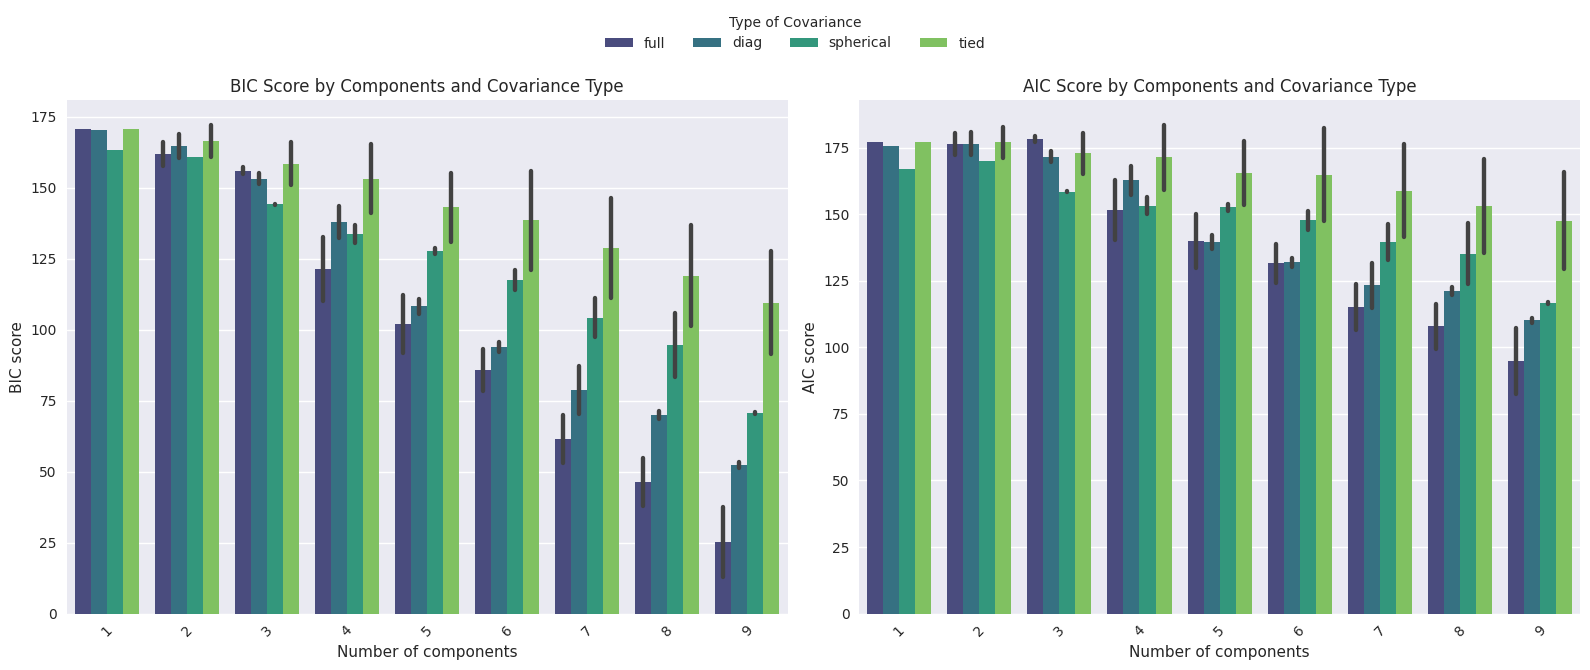

In [199]:
# 1. Crear la figura y dos subgráficos (1 fila, 2 columnas)
# IMPORTANTE: Al no usar 'sharey=True', cada gráfico tendrá su propia escala Y.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. Graficar BIC en el primer eje (ax1)
sns.barplot(
    data=search_mmg_bic_grid,
    x="Number of components",
    y="BIC score",
    hue="Type of covariance",
    ax=ax1,
    palette="viridis"
)
ax1.set_title("BIC Score by Components and Covariance Type")
ax1.tick_params(axis='x', rotation=45)

# 3. Graficar AIC en el segundo eje (ax2)
sns.barplot(
    data=search_mmg_aic_grid,
    x="Number of components",
    y="AIC score",
    hue="Type of covariance",
    ax=ax2,
    palette="viridis"
)
ax2.set_title("AIC Score by Components and Covariance Type")
# El eje Y del segundo gráfico NO se elimina, ya que tiene su propia escala.
ax2.tick_params(axis='x', rotation=45)

# 4. Manejar la leyenda compartida
# Obtener los handles y labels del primer gráfico
handles, labels = ax1.get_legend_handles_labels()

# Eliminar las leyendas individuales de los subgráficos
ax1.legend_.remove()
ax2.legend_.remove()

# Colocar la leyenda compartida en la figura
fig.legend(
    handles,
    labels,
    title="Type of Covariance",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=len(labels)
)

# 5. Ajustar el layout y mostrar el gráfico
plt.tight_layout(rect=[0, 0.03, 1, 1.05])
plt.show()

In [200]:
best_mmg_bic = mmg_bic_grid_search.best_estimator_

In [201]:
labels = best_mmg_bic.predict(X)
bogota_mb_df.loc[:,'cluster'] = labels
display(bogota_mb_df.head(3))

,restaurante,direccion,descripcion,latitud,longitud,geometry,descripcion_limpia,cluster
0,MAIKKI,Cra 75 # 24D – 48,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.668833,-74.116828,POINT (4.66883 -74.11683),"Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana",8
1,MAIKKI,Calle 119 # 11A – 24,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.698395,-74.036585,POINT (4.69839 -74.03658),"Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana",5
2,MAIKKI,Cra 47A # 98 – 47,"<p>MAIKKI MACUIRA: Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana<br/><br/>Cra 75 # 24D – 48, Modelia<br/>Calle 119 # 11A – 24, Santa Bárbara<br/>Cra 47A # 98 – 47, Castellana</p>",4.686401,-74.060144,POINT (4.68640 -74.06014),"Cama de chicharrón soplado, tocineta caramelizada en melao de maracuyá y panela de la hoya del rio Suárez, carne de res del Magdalena medio, queso fresco de pasta hilada, mayonesa de cilantro cimarrón del pacifico, cogollo de lechuga y pan artesanal. Un homenaje a lo nuestro. En pie de lucha por la comida rápida colombiana",0


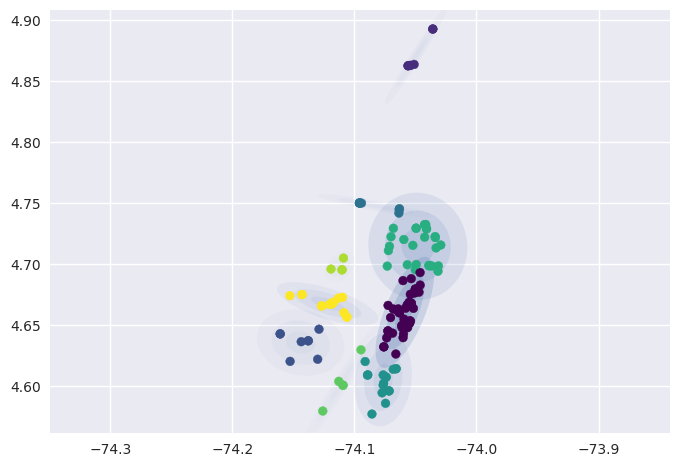

In [202]:
# Graficar
plot_gmm(best_mmg_bic, X)

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

Análisis de Puntos Calientes con Mezclas Gaussianas

Para identificar los "puntos calientes" en la distribución de restaurantes, se aplicó un modelo de Mezclas Gaussianas (GMM), utilizando las coordenadas de latitud y longitud. El objetivo de GMM en este contexto es estimar una función de densidad de probabilidad, donde las zonas de alta densidad corresponden a los puntos calientes.

Estructura de Covarianza Utilizada

La estructura de covarianza seleccionada fue 'full'.

La elección se justifica por dos razones principales:

- Validación Empírica: El procedimiento de búsqueda de hiperparámetros (GridSearchCV) evaluó cuatro tipos de covarianza (full, tied, diag, spherical). Los resultados mostraron de manera concluyente que la estructura 'full' minimizaba tanto el Criterio de Información Bayesiano (BIC) como el Criterio de Información de Akaike (AIC), indicando que es el modelo que mejor se ajusta a los datos.

- Flexibilidad del Modelo: La estructura 'full' es la más flexible, ya que permite que cada clúster (o componente) tenga su propia matriz de covarianza sin restricciones. Esto es ideal para datos geográficos, donde los grupos de restaurantes pueden formar elipses de cualquier forma, tamaño y orientación, adaptándose a la geografía de la ciudad (ej. siguiendo una avenida principal). Aunque es computacionalmente más costosa, el tamaño reducido del dataset (137 restaurantes) hace que su uso sea perfectamente factible y preferible para lograr la máxima adaptabilidad a los datos.

Selección del Número Óptimo de Componentes

El número óptimo de componentes se determinó mediante un proceso de validación cruzada, buscando el modelo que minimizara el criterio BIC. Se eligió el BIC como métrica principal porque penaliza la complejidad del modelo de forma más estricta que el AIC (considerando el número de observaciones), lo que ayuda a prevenir el sobreajuste y a seleccionar un modelo más parsimonioso.

El resultado de la búsqueda de hiperparámetros (mmg_bic_grid_search.best_params_) indicó que el valor óptimo que minimiza el BIC es 9 componentes.
Python

```bash
# Resultado del código:
{'covariance_type': 'full', 'init_params': 'kmeans', 'n_components': 9, 'random_state': 123}
```


Por lo tanto, se seleccionó un modelo final con 9 clústeres para representar las densidades de los restaurantes. Es importante aclarar que, aunque GMM se usa aquí para agrupar y visualizar los datos en clústeres, su fortaleza principal es la estimación de la densidad de probabilidad subyacente de la distribución de los puntos.

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT

#### 3.1. Visualización de los resultados

Visualice las densidades estimadas por el  mejor modelo estimado en la sección anterior usando un mapa de calor interactivo, discuta los resultados.

In [203]:
# Utilice este espacio para escribir el código.

# --- 1. Función para calcular densidad GMM en grilla ---
def calcular_gmm_grid(modelo, datos, n_grid=150):
    """
    Calcula la densidad estimada por un modelo GMM en una grilla de puntos.

    Args:
        modelo (GaussianMixture): Modelo GMM entrenado.
        datos (np.ndarray): Array con coordenadas (lon, lat).
        n_grid (int): Resolución de la grilla.

    Returns:
        tuple: (pdf_grid, grid_lon, grid_lat)
    """
    lon_min, lat_min = datos.min(axis=0) - 0.01
    lon_max, lat_max = datos.max(axis=0) + 0.01
    grid_lon, grid_lat = np.mgrid[lon_min:lon_max:n_grid*1j, lat_min:lat_max:n_grid*1j]

    puntos = np.vstack([grid_lon.ravel(), grid_lat.ravel()]).T
    pdf = np.exp(modelo.score_samples(puntos))
    pdf_grid = pdf.reshape(grid_lon.shape)

    return pdf_grid, grid_lon, grid_lat


# --- 2. Crear GeoJSON de curvas de nivel ---
def crear_geojson_contorno(pdf_grid, grid_lon, grid_lat, color_mapa='Reds'):
    fig, ax = plt.subplots(figsize=(8, 8))
    contour_plot = ax.contourf(
        grid_lon, grid_lat, pdf_grid,
        levels=15, cmap=color_mapa, alpha=0.9
    )
    plt.close(fig)
    try:
        return geojsoncontour.contourf_to_geojson(
            contourf=contour_plot,
            ndigits=5
        )
    except Exception as e:
        print(f"Error en conversión directa: {e}")
        cmap = plt.get_cmap(color_mapa)
        base_color = to_rgba(cmap(0.5))
        hex_color = '#%02x%02x%02x' % tuple([int(255 * x) for x in base_color[:3]])
        return geojsoncontour.contourf_to_geojson(
            contourf=contour_plot,
            ndigits=5,
            geojson_properties={
                'stroke': hex_color,
                'fill': hex_color,
                'stroke-width': 1,
                'fill-opacity': 0.5
            }
        )


# --- 3. Añadir capa GeoJSON al mapa ---
def agregar_capas_a_mapa(mapa, geojson_data, nombre_capa, opacidad_fondo=0.3):
    if geojson_data:
        folium.GeoJson(
            json.loads(geojson_data),
            name=nombre_capa,
            style_function=lambda feature: {
                'fillColor': feature['properties'].get('fill', '#000000'),
                'fillOpacity': opacidad_fondo,
                'color': feature['properties'].get('stroke', '#000000'),
                'weight': feature['properties'].get('stroke-width', 2),
            }
        ).add_to(mapa)
        
    else:
        print(f"❌ No se pudo añadir la capa '{nombre_capa}'.")

In [204]:
# --- 4. Calcular densidades en la grilla ---
pdf_grid, grid_lon, grid_lat = calcular_gmm_grid(best_mmg_bic, X)

# --- 5. Crear GeoJSON de curvas ---
geojson_data = crear_geojson_contorno(pdf_grid, grid_lon, grid_lat)

# --- 6. Crear mapa base ---
map_mmg_bic = folium.Map(
    location = bogota_mb_location, 
    tiles="cartodb positron",
    # crs="EPSG:4326",
    zoom_start = 11
)

# --- 7. Añadir capa de densidad ---
agregar_capas_a_mapa(map_mmg_bic, geojson_data, "Curvas de densidad GMM", opacidad_fondo=0.5)

# --- 8.1 Algo de color ---
class ClusterColor(Enum):
    # Los 5 colores originales
    CLUSTER_0 = 'red'
    CLUSTER_1 = 'orange'
    CLUSTER_2 = 'green'
    CLUSTER_3 = 'purple'
    CLUSTER_4 = 'cadetblue'
    
    # Los 5 colores adicionales que combinan bien
    # Teoria del Color hecho con Gemini 2.5
    CLUSTER_5 = 'cyan'        # Complementario del rojo, vibrante
    CLUSTER_6 = 'blue'        # Complementario del naranja, clásico
    CLUSTER_7 = 'magenta'     # Fuerte contraste para el verde, moderno
    CLUSTER_8 = 'gold'        # Complementario del púrpura, regio
    CLUSTER_9 = 'coral'       # Cálido contraste para el cadetblue

# --- 8.2 Crear grupo de características para clusters para que queden encima ptos calientes ---
cluster_group_mmg = folium.FeatureGroup(name="Puntos de Restaurantes (GMM)")
cluster_group_mmg.add_to(map_mmg_bic)

# --- 8.3 Añadir puntos individuales ---
for _, record in bogota_mb_df.iterrows():
    color:str = ClusterColor[f'CLUSTER_{record.cluster}'].value
    popup:str = template.format(
        restaurante=record.restaurante,
        direccion=record.direccion,
        descripción=record.descripcion
    )
    folium.CircleMarker(
        [record.latitud, record.longitud],
        popup=folium.Popup(popup, max_width=256),
        tooltip=record.restaurante,
        radius=8,
        fill_color=color,
        fill=True,
        color=color,
        fill_opacity=0.1,
        weight=0
    ).add_to(cluster_group_mmg)

# --- 9. Control de capas ---
folium.LayerControl().add_to(map_mmg_bic)

# --- Fallback para visualización en entornos limitados ---
try:
    display(map_mmg_bic) # Intenta mostrar en el notebook
except NameError:
    # Si 'display' no está disponible, guardar como HTML
    map_mmg_bic.save("map_mmg_bic.html")
    print("Mapa guardado como 'map_mmg_bic.html'.")

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

Discusión de Resultados del Mapa de Calor GMM

Para visualizar los puntos calientes de restaurantes, se utilizó el mejor modelo de Mezclas Gaussianas (GMM) encontrado, que consta de 9 componentes y una estructura de covarianza 'full'. Las densidades estimadas se representaron como un mapa de calor interactivo sobre Bogotá, donde las curvas de nivel con colores más intensos indican una mayor concentración de restaurantes participantes. Este método nos permite ir más allá de los puntos individuales para identificar las zonas gastronómicas clave de la ciudad.

El análisis del mapa revela un punto caliente principal y dominante que se extiende a lo largo del eje centro-norte de la ciudad. Esta zona de máxima densidad, marcada por las curvas de nivel más intensas, abarca barrios reconocidos por su alta oferta gastronómica como Chapinero, la Zona G, el Parque de la 93 y Usaquén. El modelo confirma que este corredor es el epicentro de la competencia, agrupando una gran cantidad de participantes en un área geográfica continua y bien definida.

Además del eje principal, el modelo identifica varios focos secundarios importantes, demostrando que la oferta gastronómica de alta calidad está descentralizada. Se destaca un clúster significativo en el occidente de Bogotá, en zonas como Modelia y Salitre, que representa un polo gastronómico consolidado fuera del circuito tradicional. Asimismo, el modelo es capaz de capturar concentraciones más pequeñas y aisladas, como la que se observa en el municipio de Chía, al norte de la ciudad, identificándolo como un mercado relevante pero geográficamente distinto.

En conclusión, el GMM muestra que la oferta del Burger Master, si bien está fuertemente concentrada en el corredor centro-norte, presenta una estructura multipolar con focos emergentes en el occidente y la periferia norte. Es crucial notar la principal limitación del modelo: al basarse en componentes elípticos, las curvas de densidad son una aproximación suave y pueden generalizar áreas, abarcando zonas vacías entre restaurantes. No obstante, el análisis sugiere que, para los comensales, la búsqueda de hamburguesas de alta competencia no debe limitarse a las zonas tradicionales, ya que existen mercados gastronómicos vibrantes y en crecimiento en otras partes de la ciudad y sus alrededores.

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT

### 4. Comparación con KDE

Estime ahora las densidades usando KDE bivariado de la librería `statsmodels` con el anchos de banda dado por `cv_ml`. Muestre los resultados usando un mapa interactivo. Compare los resultados obtenidos por el "mejor" modelo encontrado via MMG. 

In [205]:
# Utilice este espacio para escribir el código.
# helper
def plot_kde(pdf_grid, grid_lon, grid_lat, ax=None, cmap='viridis'):
    """
    Grafica la densidad estimada de Kernel (KDE) usando un mapa de calor.

    Args:
        pdf_grid (np.ndarray): Matriz de densidad (PDF) calculada en la grilla.
        grid_lon (np.ndarray): Malla de coordenadas de longitud (X).
        grid_lat (np.ndarray): Malla de coordenadas de latitud (Y).
        ax (plt.Axes, optional): Eje de Matplotlib para dibujar. Si es None, usa plt.gca().
        cmap (str): Mapa de colores (colormap) a utilizar. Default es 'viridis'.
    """
    ax = ax or plt.gca()
    
    # 1. Graficar el mapa de calor de la densidad
    # Usamos contourf para rellenar las áreas de densidad.
    # El número de niveles (levels) controla la suavidad del mapa.
    contour = ax.contourf(
        grid_lon, 
        grid_lat, 
        pdf_grid, 
        levels=15, # Ajusta este valor si quieres más o menos detalle
        cmap=cmap, 
        alpha=0.8,
        zorder=1 # Colocar debajo de posibles puntos de datos (si se añaden después)
    )
    
    # 2. Asegurar una escala de ejes adecuada
    ax.axis('equal')
    
    # 3. Opcional: Añadir una barra de color (colorbar) para mostrar la escala de densidad
    plt.colorbar(contour, ax=ax, label='Estimated Density (PDF)')
    
    # 4. Configuración básica de ejes
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    ax.set_title("Estimación de Densidad Kernel (KDE)")
    
    return ax

# --- 1. Funciones Modulares ---
def calcular_kde_grid(datos, bw_method='cv_ml'):
    """
    Calcula la densidad de estimación de Kernel (KDE) en una grilla de puntos.

    Args:
        datos (np.ndarray): Un array de NumPy de forma (n, 2) con longitud y latitud.
        bw_method (str): El método para el cálculo del ancho de banda ('normal_reference' o 'cv_ml').

    Returns:
        tuple: Una tupla que contiene (pdf_grid, grid_lon, grid_lat).
    """
    if datos.shape[0] < 2:
        print("No hay suficientes puntos para el cálculo KDE.")
        return None, None, None

    # Ajustamos el rango de la grilla para que se extienda un poco más allá de los puntos
    lon_min, lat_min = datos.min(axis=0) - 0.01
    lon_max, lat_max = datos.max(axis=0) + 0.01
    grid_lon, grid_lat = np.mgrid[lon_min:lon_max:150j, lat_min:lat_max:150j]

    # Transponemos los datos para que se ajusten a la entrada de KDEMultivariate
    kde = KDEMultivariate(data=datos.T, var_type='cc', bw=bw_method)
    
    pdf = kde.pdf(np.vstack([grid_lon.ravel(), grid_lat.ravel()]))
    pdf_grid = pdf.reshape(grid_lon.shape)

    return pdf_grid, grid_lon, grid_lat

<AxesSubplot:title={'center':'Estimación de Densidad Kernel (KDE)'}, xlabel='Longitud', ylabel='Latitud'>

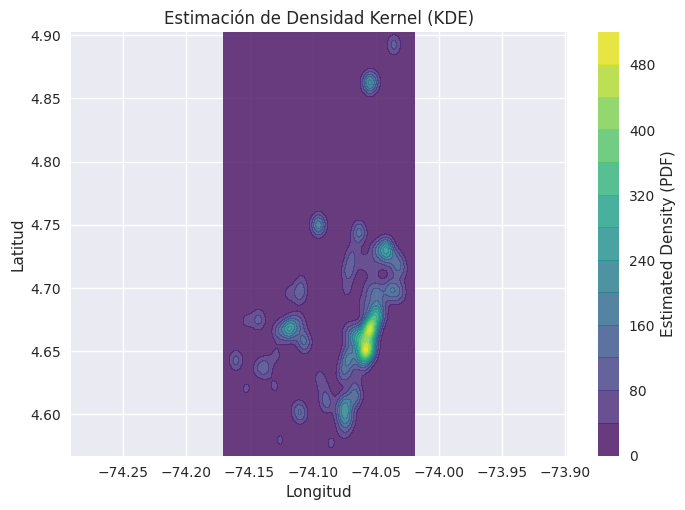

In [206]:
# --- 3. Crear KDE ---
pdf_grid, grid_lon, grid_lat = calcular_kde_grid(X)

# Graficar
plot_kde(pdf_grid, grid_lon, grid_lat)

In [207]:
# --- 2. Crear GeoJSON de curvas ---
geojson_data = crear_geojson_contorno(pdf_grid, grid_lon, grid_lat)


# --- 3. Crear mapa base ---
map_kde = folium.Map(
    location = bogota_mb_location, 
    tiles="cartodb positron",
    # crs="EPSG:4326",
    zoom_start = 11
)

# --- 4. Añadir capa de densidad ---
agregar_capas_a_mapa(map_kde, geojson_data, "Curvas de densidad GMM", opacidad_fondo=0.5)

# --- 5.1 Crear grupo de características para clusters para que queden encima ptos calientes ---
cluster_group_kde = folium.FeatureGroup(name="Puntos de Restaurantes (GMM)")
cluster_group_kde.add_to(map_kde)

# --- 5.2 Añadir puntos individuales ---
for _, record in bogota_mb_df.iterrows():
    color:str = ClusterColor[f'CLUSTER_{record.cluster}'].value
    popup:str = template.format(
        restaurante=record.restaurante,
        direccion=record.direccion,
        descripción=record.descripcion
    )
    folium.CircleMarker(
        [record.latitud, record.longitud],
        popup=folium.Popup(popup, max_width=256),
        tooltip=record.restaurante,
        radius=8,
        fill_color=color,
        fill=True,
        color=color,
        fill_opacity=0.1,
        weight=0
    ).add_to(cluster_group_kde)

# --- 6. Control de capas ---
folium.LayerControl().add_to(map_kde)

# --- Fallback para visualización en entornos limitados ---
try:
    display(map_kde) # Intenta mostrar en el notebook
except NameError:
    # Si 'display' no está disponible, guardar como HTML
    map_kde.save("map_kde.html")
    print("Mapa guardado como 'map_kde.html'.")

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

Las densidades generadas por el KDE (Kernel Density Estimation) se adaptan de forma mucho más flexible y precisa a la distribución real de los restaurantes. Esto se debe a que KDE es un método no paramétrico, lo que significa que no asume una forma predefinida para la distribución de los datos. En contraste, el GMM (Gaussian Mixture Model) es paramétrico, ya que asume que los datos provienen de una mezcla de distribuciones Gaussianas (elípticas). Como se ve en las imágenes, esto hace que GMM genere contornos suaves y generalizados que pueden agrupar múltiples focos de actividad en un único clúster grande, mientras que KDE es capaz de delinear los límites de cada foco de manera independiente y con mayor detalle.

Esta diferencia es evidente en varias zonas. Por ejemplo, en el occidente de la ciudad, donde GMM identifica un gran clúster de baja intensidad, KDE revela un punto caliente mucho más denso y específico (como el que mencionas cerca de la Cra. 75 con Cll. 24). De manera similar, en el norte, GMM podría usar un solo componente para cubrir toda la zona de Chía, mientras que KDE distingue claramente dos concentraciones de restaurantes separadas. Esta capacidad de KDE para capturar la estructura local y las formas irregulares de los datos proporciona un mapa de "puntos calientes" significativamente más fino y accionable.

En conclusión, la elección entre ambos modelos implica un balance. KDE, aunque computacionalmente más intensivo, es superior para un análisis de hotspots detallado, ya que se ajusta fielmente a la distribución espacial real. Por otro lado, GMM es más rápido y muy eficaz para identificar clústeres más amplios y bien definidos, como zonas gastronómicas generales. Una excelente estrategia de análisis sería usar GMM para obtener un primer vistazo de las principales áreas de concentración y luego aplicar KDE para profundizar y delimitar con precisión los puntos calientes dentro de esas áreas.

> Nota: Comentarios que se parafrasearon, acotaron y/o complementaron del producido inicialmente por ChatGPT